#CELL 0: Environment Setup & Repository Cloning

In [1]:
# 1. Clone your repository (Replace with your exact repo URL if different)
!git clone https://github.com/shawkath73/Subtype-HM-optimized.git

# 2. Change directory into the project
%cd Subtype-HM-optimized

# 3. Install required dependencies
!pip install torch torchvision torchaudio
!pip install scikit-learn pandas numpy matplotlib seaborn lifelines faiss-cpu

Cloning into 'Subtype-HM-optimized'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 74 (delta 17), reused 64 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 16.93 MiB | 13.17 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/Subtype-HM-optimized
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 14.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=aa4fb17a4dc69ca35d5358ec98e8da24908ba4ca3256f6d808b0ba43931d9f1c
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


#Cell 1: Setup, Path Fix, and Data Loading

In [2]:
import sys
import os

# --- FIX: BYPASS THE NESTED FOLDER ---
repo_path = '/content/Subtype-HM-optimized/Subtype-HM'
if os.path.exists(repo_path):
    sys.path.append(repo_path)
    os.chdir(repo_path)
    print(f"Successfully entered project directory: {os.getcwd()}")
else:
    print(f"Warning: {repo_path} not found. Check your clone path.")

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

# Import custom modules
from Subtype_HM import Network
from dataloader_brca import load_brca_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs('./results', exist_ok=True)

# Load Shared Data
dataset, dims, data_size = load_brca_data()
data_loader = DataLoader(dataset, batch_size=256, shuffle=False)

CLASS_NUM = 5
subtype_names = ['Luminal A', 'Luminal B', 'HER2-enriched', 'Basal-like', 'Normal-like']

# Global arrays to store results across cells
true_labels = []
single_omic_preds = []
multi_omic_probs = []
multi_omic_preds = []

Successfully entered project directory: /content/Subtype-HM-optimized/Subtype-HM
[cache] Loading brca_mrna.csv
[cache] Loading brca_methy.csv
[cache] Loading brca_mirna.csv
[cache] Loading brca_clinical_xena.tsv
[survival] Loaded 1228 real TCGA BRCA survival records.
[Variance] Selecting top 1500 features by variance for mRNA...
[Variance] mRNA: selected 1000 / 1000 features.
[Variance] Selecting top 1500 features by variance for Methylation...
[Variance] Methylation: selected 1000 / 1000 features.
[Variance] Selecting top 1500 features by variance for miRNA...
[Variance] miRNA: selected 503 / 503 features.
[BRCA] mRNA features   : 1000
[BRCA] Methylation feat: 1000
[BRCA] miRNA features  : 503
[BRCA] Samples         : 875
[BRCA] Survival — events (dead): 175/875 (20.0%)


# CELL 2: Define Single-Omic Hypergraph Network

In [4]:
import torch
import torch.nn as nn
from HIL import HypergraphConstruction, HypergraphPropagationModule
from Subtype_HM import Encoder, Decoder

class SingleOmicNetwork(nn.Module):
    """
    Same hypergraph architecture as Network, but for exactly 1 omic view.
    Bypasses MultiModalClassifier (hardcoded for 3 views).
    Uses a simple linear domain projection instead.
    """
    def __init__(self, input_dim, feature_dim, class_num, layer_num, device):
        super(SingleOmicNetwork, self).__init__()
        self.device = device
        self.feature_dim = feature_dim
        self.class_num = class_num

        self.encoder = Encoder(input_dim, feature_dim).to(device)
        self.decoder = Decoder(input_dim, feature_dim).to(device)

        self.hypergraph_constructor = HypergraphConstruction(k=20)
        self.hypergraph = HypergraphPropagationModule(
            input_dim=feature_dim,
            hidden_dim=feature_dim,
            output_dim=feature_dim,
            dk=64,
            layer_num=layer_num
        )

        # Simple linear projection replacing MultiModalClassifier
        # (feature_dim from hypergraph) + (feature_dim from linear proj) = feature_dim * 2
        self.domain_proj = nn.Linear(feature_dim, feature_dim)

        self.label_contrastive_module = nn.Sequential(
            nn.Linear(feature_dim * 2, class_num),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        """x: tensor of shape (batch, input_dim)"""
        z = self.encoder(x)                        # (N, feature_dim)
        zs = [z]                                   # wrap as list for hypergraph

        X = z                                      # single view, no cat needed
        H_s, H_o, H_c = self.hypergraph_constructor.construct_full_hypergraph(
            zs, cluster_num=self.class_num
        )
        X_updated = self.hypergraph(X, zs, H_s, H_o, H_c)  # tuple of 1 tensor

        z_hyp = X_updated[0]                       # (N, feature_dim)
        z_proj = self.domain_proj(z)               # (N, feature_dim)

        z_cat = torch.cat([z_hyp, z_proj], dim=1) # (N, feature_dim*2)
        q = self.label_contrastive_module(z_cat)   # (N, class_num)
        xr = self.decoder(z)
        return q, xr, z

    def forward_pre(self, x):
        z = self.encoder(x)
        xr = self.decoder(z)
        return xr, z

    def forward_cluster(self, x):
        q, _, z = self.forward(x)
        pred = torch.argmax(q, dim=1)
        return q, pred


# ── Monkey-patch HypergraphConstruction to clamp k safely ──
_orig_modality = HypergraphConstruction.construct_modality_hypergraph

def _safe_modality_hypergraph(self, X, k):
    safe_k = min(k, X.shape[0] - 1)
    return _orig_modality(self, X, safe_k)

HypergraphConstruction.construct_modality_hypergraph = _safe_modality_hypergraph
print("✅ Patched HypergraphConstruction.construct_modality_hypergraph with safe k clamping")

# ── Quick sanity check ──────────────────────────────────────
_test_input = torch.randn(8, dims[0]).to(device)
_so_test = SingleOmicNetwork(
    input_dim=dims[0], feature_dim=32, class_num=CLASS_NUM,
    layer_num=3, device=device
).to(device)
_q, _xr, _z = _so_test(_test_input)
print(f"✅ SingleOmicNetwork OK — q:{_q.shape}, xr:{_xr.shape}, z:{_z.shape}")
del _so_test, _test_input, _q, _xr, _z

✅ Patched HypergraphConstruction.construct_modality_hypergraph with safe k clamping
✅ SingleOmicNetwork OK — q:torch.Size([8, 5]), xr:torch.Size([8, 1000]), z:torch.Size([8, 32])


# CELL 3: Train Single-Omic Hypergraph Model — mRNA (View 0)

In [11]:
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
from MCEA import Align_Loss

FEATURE_DIM  = 32
LAYER_NUM    = 3
LR           = 0.0005
MSE_EPOCHS   = 10
CON_EPOCHS   = 400
BATCH_SIZE   = 1024
SUP_WEIGHT   = 200.0

torch.manual_seed(10)
os.makedirs('./models', exist_ok=True)

def train_single_omic(view_idx, view_name, input_dim, save_path):
    """
    Train a SingleOmicNetwork on one omic view.
    view_idx  : index into the xs list returned by the DataLoader (0=mRNA, 1=Meth, 2=miRNA)
    view_name : human-readable label for printing
    input_dim : feature dimension of that view
    save_path : where to save the .pth checkpoint
    """
    print(f"\n{'='*55}")
    print(f"  Training Single-Omic Model — {view_name}")
    print(f"  Input dim: {input_dim}  |  View index: {view_idx}")
    print(f"{'='*55}")

    model = SingleOmicNetwork(
        input_dim=input_dim,
        feature_dim=FEATURE_DIM,
        class_num=CLASS_NUM,
        layer_num=LAYER_NUM,
        device=device
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=MSE_EPOCHS + CON_EPOCHS, eta_min=1e-6
    )
    mse_fn = nn.MSELoss()
    nll_fn = nn.NLLLoss()

    loader = DataLoader(
        dataset, batch_size=BATCH_SIZE,
        shuffle=True, drop_last=False, num_workers=0
    )

    # ── Phase 1: Autoencoder pretraining ──────────────────
    print("  Phase 1: Autoencoder Pretraining")
    for epoch in range(1, MSE_EPOCHS + 1):
        model.train()
        tot = 0.
        for xs, _, _, _ in loader:
            x = xs[view_idx].to(device)
            optimizer.zero_grad()
            xr, z = model.forward_pre(x)
            loss = mse_fn(x, xr)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot += loss.item()
        scheduler.step()
        if epoch % 5 == 0 or epoch == 1:
            print(f"    [Pre] Epoch {epoch:>3}/{MSE_EPOCHS}  Loss: {tot/len(loader):.6f}")

    # ── Phase 2: Contrastive + Supervised training ────────
    print("  Phase 2: Contrastive + Supervised Training")
    for epoch in range(1, CON_EPOCHS + 1):
        model.train()
        tot = 0.
        for xs, _, _, labels in loader:
            x      = xs[view_idx].to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            q, xr, z = model(x)

            loss_recon = mse_fn(x, xr)
            loss_sup   = nll_fn(torch.log(q + 1e-8), labels)
            loss_ent   = (-(q * torch.log(q + 1e-8)).sum(dim=1)).mean()

            loss = loss_recon + loss_ent + loss_sup * SUP_WEIGHT
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tot += loss.item()

        scheduler.step()
        if epoch % 80 == 0 or epoch == 1:
            print(f"    [Con] Epoch {epoch:>3}/{CON_EPOCHS}  Loss: {tot/len(loader):.6f}")

    torch.save(model.state_dict(), save_path)
    print(f"\n  ✅ Saved → {save_path}")
    return model

# ── Train mRNA ─────────────────────────────────────────────
_mrna_dim = dataset[0][0][0].shape[0]
print(f"Building mRNA model with input_dim={_mrna_dim}  (expected 1000)")

so_model_mrna = train_single_omic(
    view_idx=0,
    view_name="mRNA Expression",
    input_dim=_mrna_dim,
    save_path='./models/BRCA_SingleOmic_mRNA.pth'
)

Building mRNA model with input_dim=1000  (expected 1000)

  Training Single-Omic Model — mRNA Expression
  Input dim: 1000  |  View index: 0
  Phase 1: Autoencoder Pretraining
    [Pre] Epoch   1/10  Loss: 0.441322
    [Pre] Epoch   5/10  Loss: 0.191628
    [Pre] Epoch  10/10  Loss: 0.110197
  Phase 2: Contrastive + Supervised Training
    [Con] Epoch   1/400  Loss: 327.497101
    [Con] Epoch  80/400  Loss: 42.163673
    [Con] Epoch 160/400  Loss: 30.994070
    [Con] Epoch 240/400  Loss: 27.196253
    [Con] Epoch 320/400  Loss: 28.007633
    [Con] Epoch 400/400  Loss: 27.600174

  ✅ Saved → ./models/BRCA_SingleOmic_mRNA.pth


# CELL 4: Train Single-Omic Hypergraph Model — Methylation (View 1)

In [12]:
torch.manual_seed(10)

# Read dim directly from dataset to avoid dims[] index confusion
_meth_dim = dataset[0][0][1].shape[0]   # xs[1] = Methylation
print(f"Building Methylation model with input_dim={_meth_dim}  (expected 1000)")

so_model_meth = train_single_omic(
    view_idx=1,
    view_name="DNA Methylation",
    input_dim=_meth_dim,
    save_path='./models/BRCA_SingleOmic_Meth.pth'
)

Building Methylation model with input_dim=1000  (expected 1000)

  Training Single-Omic Model — DNA Methylation
  Input dim: 1000  |  View index: 1
  Phase 1: Autoencoder Pretraining
    [Pre] Epoch   1/10  Loss: 0.535872
    [Pre] Epoch   5/10  Loss: 0.227613
    [Pre] Epoch  10/10  Loss: 0.122365
  Phase 2: Contrastive + Supervised Training
    [Con] Epoch   1/400  Loss: 325.609711
    [Con] Epoch  80/400  Loss: 58.259651
    [Con] Epoch 160/400  Loss: 34.848656
    [Con] Epoch 240/400  Loss: 31.346893
    [Con] Epoch 320/400  Loss: 29.201752
    [Con] Epoch 400/400  Loss: 30.361750

  ✅ Saved → ./models/BRCA_SingleOmic_Meth.pth


# CELL 5: Train Single-Omic Hypergraph Model — miRNA (View 2)

In [14]:
torch.manual_seed(10)

_mirna_dim = dataset[0][0][2].shape[0]
print(f"Building miRNA model with input_dim={_mirna_dim}  (expected 503)")

so_model_mirna = train_single_omic(
    view_idx=2,
    view_name="miRNA Expression",
    input_dim=_mirna_dim,
    save_path='./models/BRCA_SingleOmic_miRNA.pth'
)

Building miRNA model with input_dim=503  (expected 503)

  Training Single-Omic Model — miRNA Expression
  Input dim: 503  |  View index: 2
  Phase 1: Autoencoder Pretraining
    [Pre] Epoch   1/10  Loss: 0.340136
    [Pre] Epoch   5/10  Loss: 0.161647
    [Pre] Epoch  10/10  Loss: 0.110681
  Phase 2: Contrastive + Supervised Training
    [Con] Epoch   1/400  Loss: 329.747375
    [Con] Epoch  80/400  Loss: 33.473637
    [Con] Epoch 160/400  Loss: 30.466364
    [Con] Epoch 240/400  Loss: 28.616062
    [Con] Epoch 320/400  Loss: 27.833572
    [Con] Epoch 400/400  Loss: 26.311258

  ✅ Saved → ./models/BRCA_SingleOmic_miRNA.pth


# CELL 6: Load Multi-Omic Checkpoint & Run Inference — All 4 Models

In [16]:
from sklearn.preprocessing import label_binarize

eval_loader = DataLoader(
    dataset, batch_size=256,
    shuffle=False, drop_last=False, num_workers=0
)

# ── Load multi-omic checkpoint ────────────────────────────
checkpoint = torch.load('./models/BRCA.pth', map_location=device)

saved_dims = []
v = 0
while f'encoders.{v}.encoder.0.weight' in checkpoint:
    saved_dims.append(checkpoint[f'encoders.{v}.encoder.0.weight'].shape[1])
    v += 1
print(f"Multi-omic checkpoint dims (saved order): {saved_dims}")

mo_model = Network(
    view=3,
    input_size=saved_dims,
    feature_dim=FEATURE_DIM,
    class_num=CLASS_NUM,
    layer_num=LAYER_NUM,
    device=device
).to(device)
mo_model.load_state_dict(checkpoint)
mo_model.eval()
print("✅ Multi-omic model loaded from ./models/BRCA.pth")

# ── Build checkpoint→dataset slot mapping ─────────────────
dataset_dims = [dataset[0][0][v].shape[0] for v in range(3)]
print(f"Dataset xs dims: {dataset_dims}")
checkpoint_to_dataset = []
for sd in saved_dims:
    for dv, dd in enumerate(dataset_dims):
        if dd == sd and dv not in checkpoint_to_dataset:
            checkpoint_to_dataset.append(dv)
            break
print(f"Checkpoint→dataset slot mapping: {checkpoint_to_dataset}")

# ── Reload single-omic models from saved checkpoints ─────
# (safe to re-run even if already in memory from training cells)
def load_so_model(input_dim, path):
    m = SingleOmicNetwork(
        input_dim=input_dim, feature_dim=FEATURE_DIM,
        class_num=CLASS_NUM, layer_num=LAYER_NUM, device=device
    ).to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    return m

# ── Reload single-omic models from saved checkpoints ─────
so_model_mrna  = load_so_model(dataset[0][0][0].shape[0], './models/BRCA_SingleOmic_mRNA.pth')
so_model_meth  = load_so_model(dataset[0][0][1].shape[0], './models/BRCA_SingleOmic_Meth.pth')
so_model_mirna = load_so_model(dataset[0][0][2].shape[0], './models/BRCA_SingleOmic_miRNA.pth')
print("✅ All three single-omic models loaded")

# ── Collect inference outputs ─────────────────────────────
all_labels      = []
mrna_probs_all  = []
meth_probs_all  = []
mirna_probs_all = []
mo_probs_all    = []

with torch.no_grad():
    for xs, _, _, labels in eval_loader:
        x_mrna  = xs[0].to(device)
        x_meth  = xs[1].to(device)
        x_mirna = xs[2].to(device)

        # Single-omic
        q_mrna,  _, _ = so_model_mrna(x_mrna)
        q_meth,  _, _ = so_model_meth(x_meth)
        q_mirna, _, _ = so_model_mirna(x_mirna)

        mrna_probs_all.append(q_mrna.cpu().numpy())
        meth_probs_all.append(q_meth.cpu().numpy())
        mirna_probs_all.append(q_mirna.cpu().numpy())

        # Multi-omic (average across views)
        xs_reordered = [xs[checkpoint_to_dataset[v]].to(device) for v in range(3)]
        qs_mo, _ = mo_model.forward_cluster(xs_reordered)
        mo_avg = sum([q.cpu().numpy() for q in qs_mo]) / 3.0
        mo_probs_all.append(mo_avg)

        all_labels.append(labels.numpy())

all_labels      = np.concatenate(all_labels,      axis=0)
mrna_probs_all  = np.concatenate(mrna_probs_all,  axis=0)
meth_probs_all  = np.concatenate(meth_probs_all,  axis=0)
mirna_probs_all = np.concatenate(mirna_probs_all, axis=0)
mo_probs_all    = np.concatenate(mo_probs_all,    axis=0)

mrna_preds  = np.argmax(mrna_probs_all,  axis=1)
meth_preds  = np.argmax(meth_probs_all,  axis=1)
mirna_preds = np.argmax(mirna_probs_all, axis=1)
mo_preds    = np.argmax(mo_probs_all,    axis=1)

print(f"\nSamples evaluated : {len(all_labels)}")
print(f"mRNA  ACC  : {(mrna_preds  == all_labels).mean()*100:.2f}%")
print(f"Meth  ACC  : {(meth_preds  == all_labels).mean()*100:.2f}%")
print(f"miRNA ACC  : {(mirna_preds == all_labels).mean()*100:.2f}%")
print(f"Multi ACC  : {(mo_preds    == all_labels).mean()*100:.2f}%")

Multi-omic checkpoint dims (saved order): [1000, 1000, 503]
✅ Multi-omic model loaded from ./models/BRCA.pth
Dataset xs dims: [1000, 1000, 503]
Checkpoint→dataset slot mapping: [0, 1, 2]
✅ All three single-omic models loaded

Samples evaluated : 875
mRNA  ACC  : 90.17%
Meth  ACC  : 90.51%
miRNA ACC  : 90.06%
Multi ACC  : 91.66%


# CELL 7: Side-by-Side Metrics — ACC / NMI / ARI (All 4 Models)

In [17]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment

def cluster_accuracy(y_true, y_pred, n_classes):
    """Hungarian-matched accuracy."""
    cost = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cost[t, p] += 1
    row, col = linear_sum_assignment(-cost)
    return cost[row, col].sum() / len(y_true)

models_info = [
    ("mRNA only",        mrna_preds),
    ("Methylation only", meth_preds),
    ("miRNA only",       mirna_preds),
    ("Multi-Omic",       mo_preds),
]

results = {}
for name, preds in models_info:
    results[name] = {
        'ACC': cluster_accuracy(all_labels, preds, CLASS_NUM),
        'NMI': normalized_mutual_info_score(all_labels, preds),
        'ARI': adjusted_rand_score(all_labels, preds),
    }

# ── Pretty print ──────────────────────────────────────────
header = f"{'Metric':<8}" + "".join(f"{n:>22}" for n, _ in models_info)
print("\n" + "="*96)
print(header)
print("="*96)
for metric in ['ACC', 'NMI', 'ARI']:
    row = f"{metric:<8}"
    for name, _ in models_info:
        v = results[name][metric]
        row += f"{v*100 if metric=='ACC' else v:>21.{'2f' if metric=='ACC' else '4f'}}"
        if metric == 'ACC':
            row += "%"
    print(row)
print("="*96)

# Save to file
with open('./results/AllModels_comparison.txt', 'w') as f:
    f.write(header + "\n" + "="*96 + "\n")
    for metric in ['ACC', 'NMI', 'ARI']:
        row = f"{metric:<8}"
        for name, _ in models_info:
            v = results[name][metric]
            row += f"{v*100 if metric=='ACC' else v:>21.{'2f' if metric=='ACC' else '4f'}}"
            if metric == 'ACC':
                row += "%"
        f.write(row + "\n")
    f.write("="*96 + "\n")
print("✅ Saved → ./results/AllModels_comparison.txt")


Metric               mRNA only      Methylation only            miRNA only            Multi-Omic
ACC                     90.17%                90.51%                90.06%                91.66%
NMI                    0.7570               0.7672               0.7679               0.7831
ARI                    0.8225               0.8211               0.8186               0.8570
✅ Saved → ./results/AllModels_comparison.txt


# CELL 8: ROC Curves — All 4 Models (one subplot each)

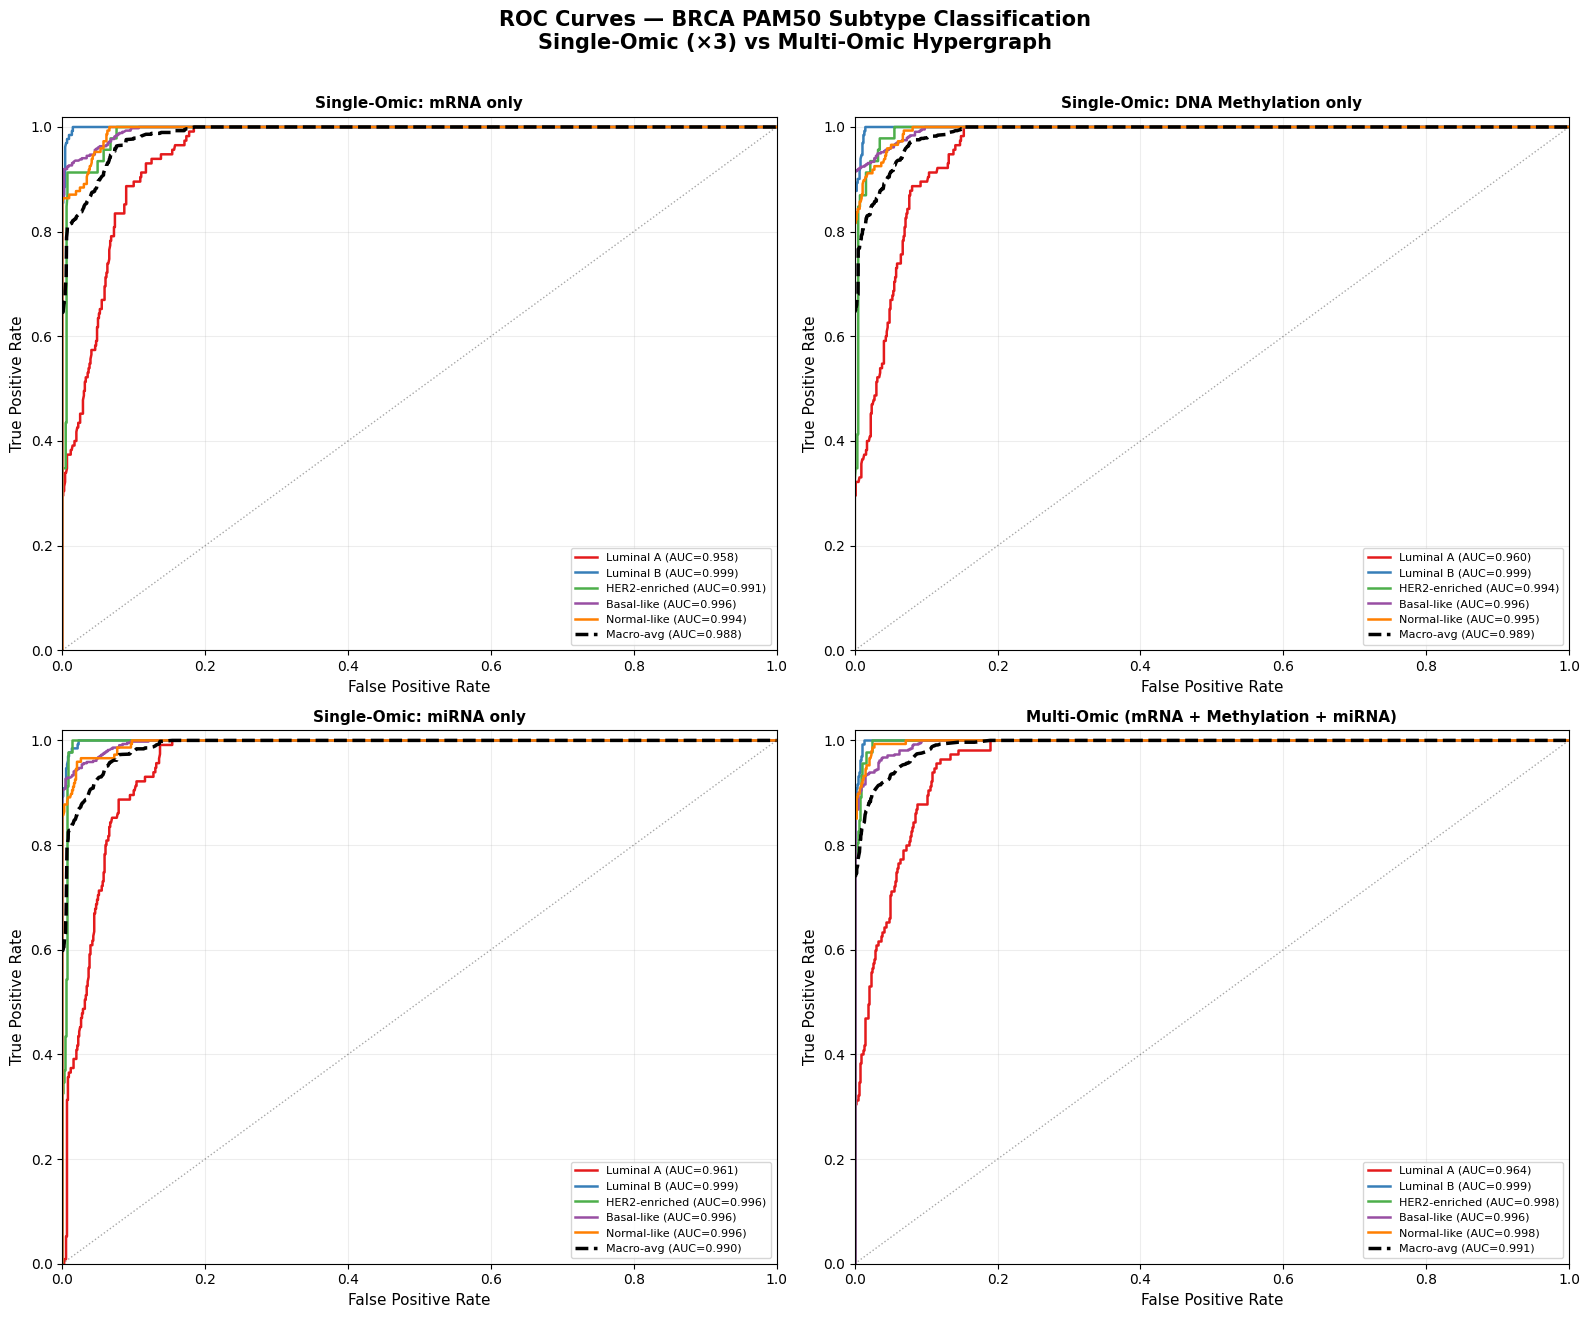

✅ Saved → ./results/ROC_AllModels.png


In [18]:
from sklearn.metrics import roc_curve, auc

y_bin  = label_binarize(all_labels, classes=list(range(CLASS_NUM)))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

all_model_probs = [
    (mrna_probs_all,  "Single-Omic: mRNA only"),
    (meth_probs_all,  "Single-Omic: DNA Methylation only"),
    (mirna_probs_all, "Single-Omic: miRNA only"),
    (mo_probs_all,    "Multi-Omic (mRNA + Methylation + miRNA)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle(
    'ROC Curves — BRCA PAM50 Subtype Classification\n'
    'Single-Omic (×3) vs Multi-Omic Hypergraph',
    fontsize=15, fontweight='bold', y=1.01
)
axes = axes.flatten()

for ax, (probs, title) in zip(axes, all_model_probs):
    # Per-class ROC curves
    for i, (name, color) in enumerate(zip(subtype_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{name} (AUC={roc_auc:.3f})')

    # Macro-average ROC
    all_fpr = np.unique(np.concatenate(
        [roc_curve(y_bin[:, i], probs[:, i])[0] for i in range(CLASS_NUM)]
    ))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(CLASS_NUM):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], probs[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)
    mean_tpr /= CLASS_NUM
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
            label=f'Macro-avg (AUC={macro_auc:.3f})')

    ax.plot([0,1],[0,1], 'k:', lw=1, alpha=0.35)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.22)

plt.tight_layout()
plt.savefig('./results/ROC_AllModels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → ./results/ROC_AllModels.png")

# CELL 9: Confusion Matrices — All 4 Models (one subplot each)

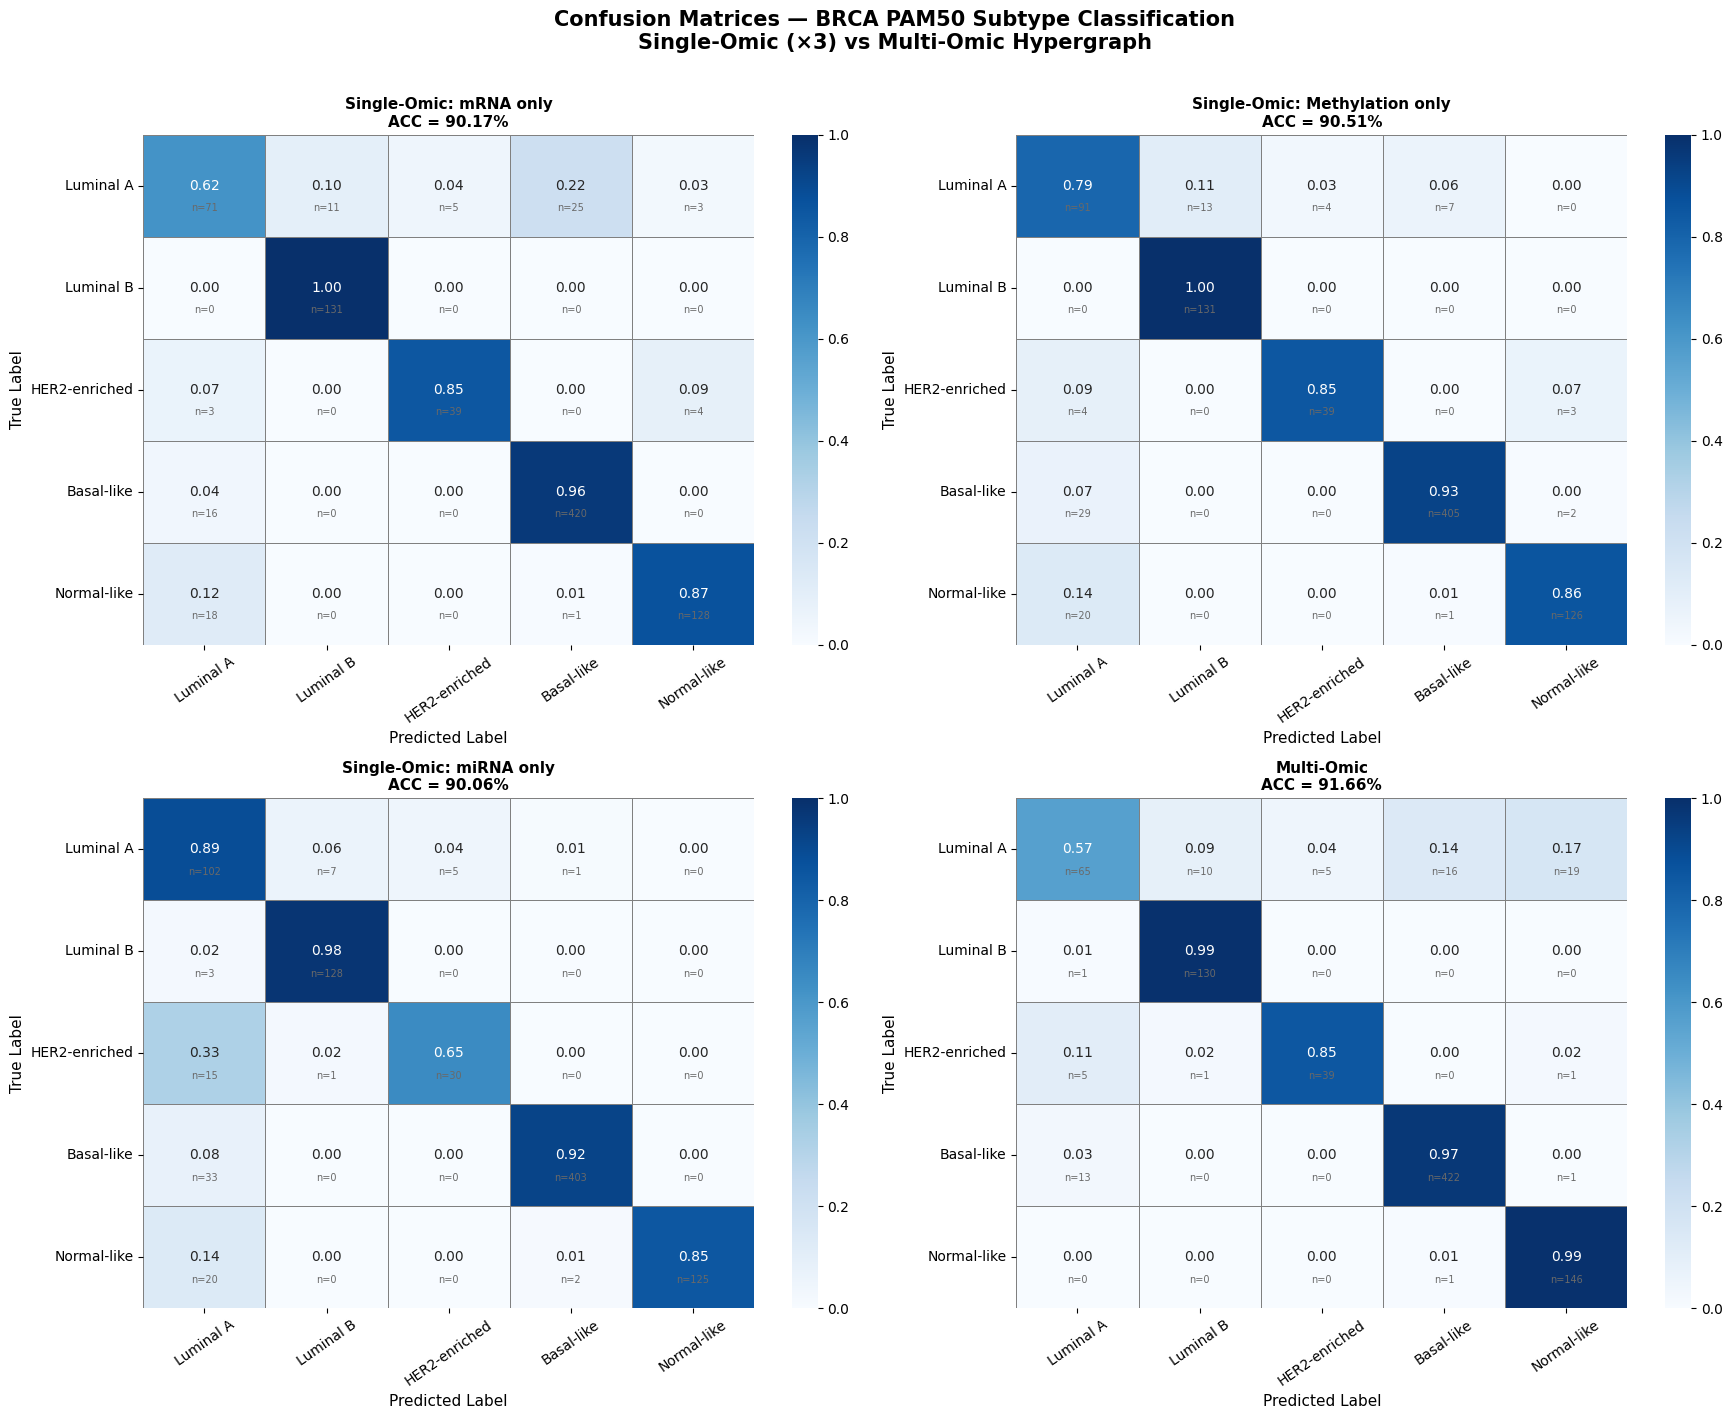

✅ Saved → ./results/ConfusionMatrix_AllModels.png

🎉 Full pipeline complete. All results saved to ./results/


In [19]:
from sklearn.metrics import confusion_matrix

def hungarian_remap(y_true, y_pred, n_classes):
    """Remap cluster IDs to best-matching true labels via Hungarian algorithm."""
    cost = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cost[t, p] += 1
    row, col = linear_sum_assignment(-cost)
    mapping = {c: r for r, c in zip(row, col)}
    return np.array([mapping.get(p, p) for p in y_pred])

all_model_preds = [
    (mrna_preds,  "Single-Omic: mRNA only",        results["mRNA only"]['ACC']),
    (meth_preds,  "Single-Omic: Methylation only",  results["Methylation only"]['ACC']),
    (mirna_preds, "Single-Omic: miRNA only",         results["miRNA only"]['ACC']),
    (mo_preds,    "Multi-Omic",                      results["Multi-Omic"]['ACC']),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(
    'Confusion Matrices — BRCA PAM50 Subtype Classification\n'
    'Single-Omic (×3) vs Multi-Omic Hypergraph',
    fontsize=15, fontweight='bold', y=1.01
)
axes = axes.flatten()

for ax, (preds, title, acc) in zip(axes, all_model_preds):
    preds_mapped = hungarian_remap(all_labels, preds, CLASS_NUM)
    cm      = confusion_matrix(all_labels, preds_mapped)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', ax=ax,
        cmap='Blues', linewidths=0.5, linecolor='gray',
        xticklabels=subtype_names, yticklabels=subtype_names,
        vmin=0, vmax=1, annot_kws={"size": 10}
    )
    # Overlay raw counts
    for i in range(CLASS_NUM):
        for j in range(CLASS_NUM):
            ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                    ha='center', va='center', fontsize=7, color='dimgray')

    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{title}\nACC = {acc*100:.2f}%', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('./results/ConfusionMatrix_AllModels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved → ./results/ConfusionMatrix_AllModels.png")
print("\n🎉 Full pipeline complete. All results saved to ./results/")